delay_line_sim_with_aligner

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Function to calculate the endpoints of a mirror given center, length, and angle
def calculate_mirror_endpoints(center, length, angle):
    half_length = length / 2
    angle_rad = np.radians(angle)
    start = (
        center[0] - half_length * np.cos(angle_rad),
        center[1] - half_length * np.sin(angle_rad),
    )
    end = (
        center[0] + half_length * np.cos(angle_rad),
        center[1] + half_length * np.sin(angle_rad),
    )
    return start, end

# Function to find the intersection of two lines
def find_intersection(p1, p2, p3, p4):
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    x4, y4 = p4
    A1, B1, C1 = y2 - y1, x1 - x2, x1 * y2 - y1 * x2
    A2, B2, C2 = y4 - y3, x3 - x4, x3 * y4 - y3 * x4
    det = A1 * B2 - A2 * B1
    if det == 0:
        return None  # Lines are parallel
    x = (B2 * C1 - B1 * C2) / det
    y = (A1 * C2 - A2 * C1) / det
    # Check if the intersection is within both line segments
    if (min(x1, x2) <= x <= max(x1, x2) and min(y1, y2) <= y <= max(y1, y2) and
        min(x3, x4) <= x <= max(x3, x4) and min(y3, y4) <= y <= max(y3, y4)):
        return (x, y)
    return None

# Function to calculate the reflection of a laser beam
def reflect_laser(laser_start, laser_angle, mirrors, last_mirror):
    laser_angle_rad = np.radians(laser_angle)
    laser_far_end = (
        laser_start[0] + np.cos(laser_angle_rad) * 1000,
        laser_start[1] + np.sin(laser_angle_rad) * 1000,
    )
    
    closest_intersection = None
    closest_mirror = None
    min_distance = float('inf')

    # Find the closest intersection, ignoring the last mirror hit
    for mirror in mirrors:
        if mirror == last_mirror:
            continue
        intersection = find_intersection(laser_start, laser_far_end, mirror[0], mirror[1])
        if intersection is not None:
            distance = np.linalg.norm(np.array(intersection) - np.array(laser_start))
            if distance < min_distance:
                min_distance = distance
                closest_intersection = intersection
                closest_mirror = mirror

    if closest_intersection is None:
        return None, None, None  # No reflection
    
    # Reflection calculation
    mirror_start, mirror_end = closest_mirror
    mirror_vector = np.array([mirror_end[0] - mirror_start[0], mirror_end[1] - mirror_start[1]])
    mirror_length = np.linalg.norm(mirror_vector)
    mirror_unit_vector = mirror_vector / mirror_length
    normal_vector = np.array([-mirror_unit_vector[1], mirror_unit_vector[0]])
    incident_vector = np.array([closest_intersection[0] - laser_start[0], closest_intersection[1] - laser_start[1]])
    reflection_vector = (
        incident_vector - 2 * np.dot(incident_vector, normal_vector) * normal_vector
    )
    reflected_end = (
        closest_intersection[0] + reflection_vector[0],
        closest_intersection[1] + reflection_vector[1],
    )
    return closest_intersection, reflected_end, closest_mirror

In [3]:
# Function to calculate distance between two points
def calculate_distance(p1, p2):
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)

# Simulate laser reflections with length calculation    
def simulate_laser_with_length(laser_start, laser_angle, mirrors, max_reflections=36):
    current_position = laser_start
    current_angle = laser_angle
    last_mirror = None
    laser_path = [laser_start]  # Track laser path

    for _ in range(max_reflections):
        intersection, reflected_end, hit_mirror = reflect_laser(current_position, current_angle, mirrors, last_mirror)
        if intersection is None:
            # No more intersections; add final endpoint and break
            laser_far_end = (
                current_position[0] + np.cos(np.radians(current_angle)) * 1000,
                current_position[1] + np.sin(np.radians(current_angle)) * 1000,
            )
            laser_path.append(laser_far_end)
            break

        # Update the path and continue simulation
        laser_path.append(intersection)
        current_position = intersection
        current_angle = np.degrees(np.arctan2(
            reflected_end[1] - intersection[1],
            reflected_end[0] - intersection[0],
        ))
        last_mirror = hit_mirror

    # Calculate total laser length
    total_length = sum(calculate_distance(laser_path[i], laser_path[i + 1]) for i in range(len(laser_path) - 2))
    return laser_path, total_length

def extend_line(p1, p2):
    # Calculate the length of the line
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    # Extend the line in both directions
    new_p1 = (p1[0] - 0.73*dx, p1[1] - 0.73*dy)  # Extend p1 backwards
    new_p2 = (p2[0] + 0.73*dx, p2[1] + 0.73*dy)  # Extend p2 forwards
    return new_p1, new_p2

def create_orthogonal_line_at_endpoint(endpoint, other_endpoint, length=44):
    """Create an orthogonal line of the specified length at a given endpoint."""
    # Calculate the direction vector of the original line
    dx = other_endpoint[0] - endpoint[0]
    dy = other_endpoint[1] - endpoint[1]
    
    # Get orthogonal direction
    orthogonal_dx = -dy
    orthogonal_dy = dx
    magnitude = np.sqrt(orthogonal_dx**2 + orthogonal_dy**2)
    unit_dx = orthogonal_dx / magnitude
    unit_dy = orthogonal_dy / magnitude

    # Compute the two endpoints of the orthogonal line
    ortho_p1 = (endpoint[0] + unit_dx * length, endpoint[1] + unit_dy * length)
    ortho_p2 = (endpoint[0] - unit_dx * length, endpoint[1] - unit_dy * length)
    return ortho_p1, ortho_p2

def select_furthest_orthogonal_line(endpoint, ortho_p1, ortho_p2, reference_x=100):
    """Select the orthogonal line endpoint furthest away from reference_x."""
    # Calculate distances from reference_x for each orthogonal endpoint
    dist_ortho_p1 = abs(ortho_p1[0] - reference_x)
    dist_ortho_p2 = abs(ortho_p2[0] - reference_x)
    
    # Return the endpoint further from reference_x
    if dist_ortho_p1 > dist_ortho_p2:
        return (endpoint, ortho_p1)
    else:
        return (endpoint, ortho_p2)

def process_mirrors(mirrors):
    doubled_lines = []
    orthogonal_lines = []
    
    for p1, p2 in mirrors:
        # Double the length of the original line
        extended_p1, extended_p2 = extend_line(p1, p2)
        doubled_lines.append((extended_p1, extended_p2))

        # Create orthogonal lines at the endpoints of the doubled line
        ortho_p1_a, ortho_p1_b = create_orthogonal_line_at_endpoint(extended_p1, extended_p2)
        ortho_p2_a, ortho_p2_b = create_orthogonal_line_at_endpoint(extended_p2, extended_p1)
        
        # Select only the orthogonal line furthest from x=100
        orthogonal_lines.append(select_furthest_orthogonal_line(extended_p1, ortho_p1_a, ortho_p1_b))
        orthogonal_lines.append(select_furthest_orthogonal_line(extended_p2, ortho_p2_a, ortho_p2_b))

    return doubled_lines, orthogonal_lines

In [4]:
# The diameter of usable mirror. Given 1 inch mirror: 25.4mm. Clear aperture from spec sheet: 22.9mm.
# 3mm diameter beam. 22.9 - (3/2) = 21.4 mm
mirror_lengths = [21.4, 21.4, 21.4, 21.4]

# Set up the laser
laser_start = (0, 100)
laser_angle = 0  # Initial laser angle in degrees

In [5]:
#Quad Cell Locations
qc_1 = np.array([-100, 137])
qc_2 = np.array([-300, 190])

In [6]:
def execution(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    mirrors = []

    # MIRROR CONFIGURATION
    mirror_centers = [(m1cx, m1cy), (m2cx, m2cy), (m3cx, m3cy), (m4cx, m4cy)]
    mirror_angles = [m1a, m2a, m3a, m4a] #in degrees

    for center, length, angle in zip(mirror_centers, mirror_lengths, mirror_angles):
        mirrors.append(calculate_mirror_endpoints(center, length, angle))

    # Initialize plot
    plt.figure(figsize=(12, 10))
    plt.scatter(*laser_start, color='red', label="Laser Source", linewidth=1)

    #Piezo mount outline visualizer
    doubled_lines, orthogonal_lines = process_mirrors(mirrors)

    # Draw the mirrors
    for i, mirror in enumerate(mirrors):
        plt.plot([mirror[0][0], mirror[1][0]], [mirror[0][1], mirror[1][1]], color = 'black', linewidth=3)

    #Draw piezo mirror mounts outline for fitting purposes
    for i, mirror in enumerate(doubled_lines):
        plt.plot([mirror[0][0], mirror[1][0]], [mirror[0][1], mirror[1][1]], linewidth=1, color = 'black')

    for i, mirror in enumerate(orthogonal_lines):
        plt.plot([mirror[0][0], mirror[1][0]], [mirror[0][1], mirror[1][1]], linewidth=1, color = 'black')

    # Simulate laser reflections
    max_reflections = 36
    current_position = laser_start
    current_angle = laser_angle
    last_mirror = None
    reflection_count = 0

    for i in range(max_reflections):
        intersection, reflected_end, hit_mirror = reflect_laser(current_position, current_angle, mirrors, last_mirror)
        if intersection is None:
            # No more intersections
            plt.plot(
                [current_position[0], current_position[0] + np.cos(np.radians(current_angle)) * 1000],
                [current_position[1], current_position[1] + np.sin(np.radians(current_angle)) * 1000],
                'g--'
            )
            break

        # Draw the laser and reflection
        plt.plot([current_position[0], intersection[0]], [current_position[1], intersection[1]], 'r-', linewidth =1)
        #plt.plot([intersection[0], reflected_end[0]], [intersection[1], reflected_end[1]], 'g-')
        #plt.scatter(*intersection, color='orange', label=f"Intersection {i+1}")
    
        # Update for next reflection
        current_position = intersection
        current_angle = np.degrees(np.arctan2(
            reflected_end[1] - intersection[1],
            reflected_end[0] - intersection[0],
        ))
        last_mirror = hit_mirror
        reflection_count += 1

    laser_path, total_length = simulate_laser_with_length(laser_start, laser_angle, mirrors)

    #Indicate where to cut off laser distance calculation (x=?)
    a=laser_path[-2]
    b=laser_path[-1]
    x=0
    slope = (b[1] - a[1]) / (b[0] - a[0])
    y = a[1] + slope * (x - a[0])
    x_point = (x, y)
    distance = np.sqrt((x_point[0] - a[0])**2 + (x_point[1] - a[1])**2)

    #Identify if the exiting beam gets clipped with M4
    a = np.array([a[0], a[1]])
    b = np.array([b[0], b[1]])
    m = np.array([m4cx, m4cy])
    v = b - a
    d = np.array([np.cos(np.deg2rad(m4a)), np.sin(np.deg2rad(m4a))])
    A = np.column_stack((v, -d))
    t, s = np.linalg.solve(A, m - a)
    p = a + t * v if 0 <= t <= 1 else None
    dist = np.linalg.norm(p - m)
    if dist >= 14.3: # Mirror diameter = 25.4mm. laser beam diameter = 3mm. (25.4/2) + (3/2) + 0.1(<- additional edge of mirror error)
        print("NOT CLIPPED, room to spare: ", dist-14.3, "mm")
    else:
        print("CLIPPED, ", dist-14.3, 'mm too much')

    print("Laser Path:", laser_path)
    print("Total Laser Length:", total_length+distance, "mm")
    print("Total Number of Reflection (N_R) = ", reflection_count)

    # Finalize plot
    plt.xlim(-310, 250)
    plt.ylim(-10, 210)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title("Laser Reflection with Multiple Mirrors")
    plt.xlabel("X (mm)")
    plt.ylabel("Y (mm)")
    plt.grid(True, linewidth=0.3)
    plt.plot([qc_1[0],qc_1[0]],[qc_1[1] - 2, qc_1[1] + 2], linewidth=4, label='QC1') # Quadcell Detector 1
    plt.plot([qc_2[0],qc_2[0]],[qc_2[1] - 2, qc_2[1] + 2], linewidth=4, label='QC2') # Quadcell Detector 2
    plt.legend(prop={'size': 8})
    plt.show()

NOT CLIPPED, room to spare:  2.0271582182511843 mm
Laser Path: [(0, 100), (np.float64(161.06745018261216), np.float64(100.0)), (np.float64(21.04006370830523), np.float64(66.31001585761199)), (np.float64(179.38197375018368), np.float64(66.64717406340576)), (np.float64(38.55990398115128), np.float64(107.78374493922543)), (np.float64(160.51747214101744), np.float64(104.63703361054235)), (np.float64(20.931230284415907), np.float64(67.21934546906546)), (np.float64(178.9321890271604), np.float64(63.479291455115856)), (np.float64(-787.8644440589283), np.float64(319.02629349858125))]
Total Laser Length: 1219.7754881851379 mm
Total Number of Reflection (N_R) =  7


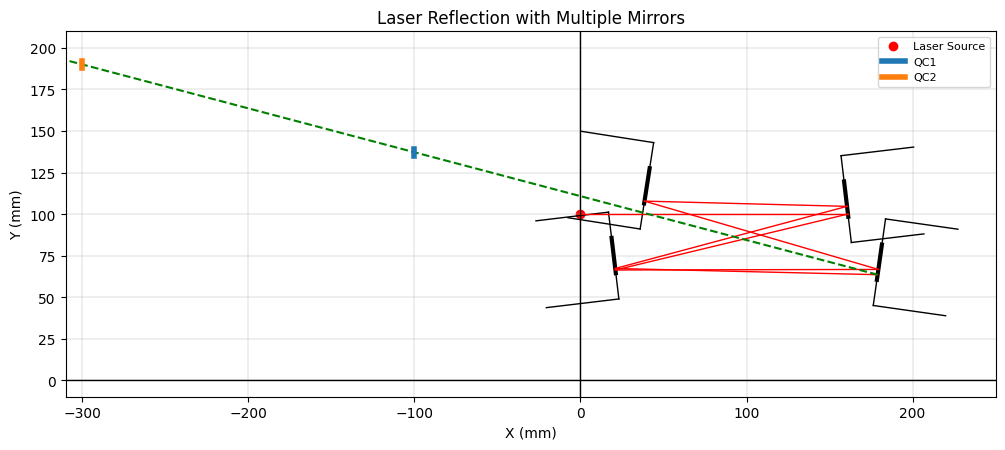

In [7]:
execution(160, 109, #M1, (x,y)
          20, 75, #M2, (x,y)
          180, 71, #M3, (x,y)
          40, 117, #M4, (x,y)
          96.764, 96.825, 81.919, 81.119) # Angle from positive x-axis (M1, M2, M3, M4)

In [8]:

def execution_identifier(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    mirrors = []

    # MIRROR CONFIGURATION
    mirror_centers = [(m1cx, m1cy), (m2cx, m2cy), (m3cx, m3cy), (m4cx, m4cy)]
    mirror_angles = [m1a, m2a, m3a, m4a] #in degrees

    for center, length, angle in zip(mirror_centers, mirror_lengths, mirror_angles):
        mirrors.append(calculate_mirror_endpoints(center, length, angle))

    #Piezo mount outline visualizer
    doubled_lines, orthogonal_lines = process_mirrors(mirrors)

    # Simulate laser reflections
    max_reflections = 36
    current_position = laser_start
    current_angle = laser_angle
    last_mirror = None

    laser_path, total_length = simulate_laser_with_length(laser_start, laser_angle, mirrors)

    #Indicate where to cut off laser distance calculation (x=?)
    a=laser_path[-2]
    b=laser_path[-1]
    x=0
    slope = (b[1] - a[1]) / (b[0] - a[0])
    y = a[1] + slope * (x - a[0])
    x_point = (x, y)
    distance = np.sqrt((x_point[0] - a[0])**2 + (x_point[1] - a[1])**2)

    last_two = laser_path[-2:]
    exit_slope = (last_two[1][1]-last_two[0][1])/(last_two[1][0]-last_two[0][0])
    y_int=last_two[1][1]-exit_slope*last_two[1][0]
    y100=exit_slope*-100+y_int
    return exit_slope, total_length+distance, y100

In [9]:

execution_identifier(160, 109, #M1, (x,y)
                     20, 75, #M2, (x,y)
                     180, 71, #M3, (x,y)
                     40, 117, #M4, (x,y)
                     96.764, 96.825, 81.919, 81.119) # Angle from positive x-axis (M1, M2, M3, M4)

(np.float64(-0.2643234298693613),
 np.float64(1219.7754881851379),
 np.float64(137.20760435974393))

In [10]:
#Old function for finding solution of J@x = b
def general_solution_with_scalar(J, b, tol=1e-10):
    """
    Solve J @ x = b and return (x0, v) s.t. all solutions are:
        x = x0 + a * v,  for any scalar a.
    If nullity = 0, v is None and the solution is unique (or least-squares if inconsistent).
    """
    J = np.asarray(J, dtype=float)
    b = np.asarray(b, dtype=float)

    # SVD: J = U[:, :r] diag(s[:r]) Vh[:r, :]
    U, s, Vh = np.linalg.svd(J, full_matrices=True)
    # rank with a robust threshold
    thresh = tol * max(J.shape) * (s[0] if s.size else 0.0)
    r = int(np.sum(s > thresh))

    # Minimum-norm particular solution using sliced SVD pieces
    # x0 = V[:, :r] @ diag(1/s[:r]) @ U[:, :r]^T @ b
    x0 = Vh.T[:, :r] @ ((U.T[:r, :] @ b) / s[:r])

    # Null-space vector: first column of V corresponding to zero singular values
    v = None
    if Vh.shape[0] > r:
        v = Vh.T[:, r]
        nrm = np.linalg.norm(v)
        if nrm > 0:
            v = v / nrm

    # (Optional) residual check; for consistent systems this is ~0
    resid = np.linalg.norm(J @ x0 - b)

    return x0, v, resid

In [11]:
#Calculates beta for qc_1 (qc_1 initialized earlier)

def calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    res = execution_identifier(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a)
    y100 = res[2]
    qc_loc1 = np.array([-100, 137])
    beta1 = y100 - qc_1[1]
    return beta1

In [12]:
def calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    res = execution_identifier(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a)
    y300 = res[2] - res[0] * 200
    qc_loc2 = np.array([-300, 190])
    beta2 = y300 - qc_2[1]
    return beta2

In [13]:
def calc_B(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a):
    B = np.zeros([2])
    B[0] = calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a)
    B[1] = calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a)
    return B

In [14]:
def calc_jacobian(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a, m4a, m1da, m2da, m3da):
    J = np.zeros([2,3])
    J[0,0] = (calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a + m1da, m2a, m3a, m4a) - calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a - m1da, m2a, m3a, m4a))/(2*m1da)
    J[0,1] = (calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a + m2da, m3a, m4a) - calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a - m2da, m3a, m4a))/(2*m2da)
    J[0,2] = (calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a + m3da, m4a) - calc_beta1(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a - m3da, m4a))/(2*m3da)
    J[1,0] = (calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a + m1da, m2a, m3a, m4a) - calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a - m1da, m2a, m3a, m4a))/(2*m1da)
    J[1,1] = (calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a + m2da, m3a, m4a) - calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a - m2da, m3a, m4a))/(2*m2da)
    J[1,2] = (calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a + m3da, m4a) - calc_beta2(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a, m2a, m3a - m3da, m4a))/(2*m3da)
    return J

    

In [15]:
#initialize mirror positions and angles

m1cx = 160
m1cy = 109 
m2cx = 9
m2cy = 75 
m3cx = 180
m3cy = 71 
m4cx = 40
m4cy = 117 
m1a0, m2a0, m3a0, m4a0 = 95.94256271, 95.68644659, 81.59282712, 81.519 



CLIPPED,  -0.09005671129004433 mm too much
Laser Path: [(0, 100), (np.float64(160.9368171792799), np.float64(100.0)), (np.float64(9.680461768435602), np.float64(68.16629580097144)), (np.float64(179.35699145493788), np.float64(66.64932360425631)), (np.float64(38.62916208347716), np.float64(107.8066558866553)), (np.float64(160.27004978161813), np.float64(106.4056325093964)), (np.float64(9.219656426537727), np.float64(72.7940464637338)), (np.float64(179.74948359666908), np.float64(69.30497462111761)), (np.float64(38.774009474255934), np.float64(108.7780558540031)), (np.float64(160.31456772283272), np.float64(105.97794877366557)), (np.float64(9.440404991938967), np.float64(70.57712485507365)), (np.float64(179.1353044568728), np.float64(65.14936159421501)), (np.float64(-786.8702479593258), np.float64(323.6706812200349))]
Total Laser Length: 1856.935025851525 mm
Total Number of Reflection (N_R) =  11


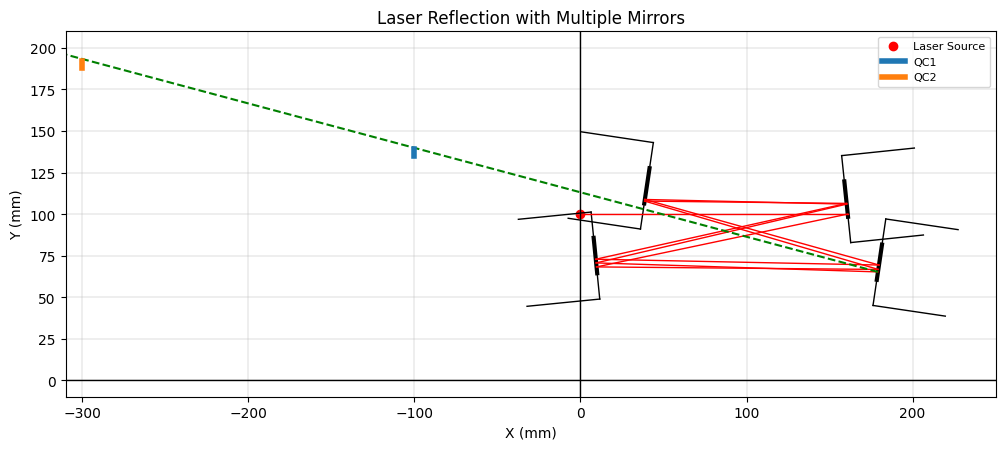

In [16]:
execution(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a0, m2a0, m3a0, m4a0)

B(alpha0) = [2.85123787 3.37501297]
Converged: True iters: 5 
reason: ||B|| <= tol_beta
Final Angles [m1, m2, m3, m4] = [95.95269655 95.67222305 81.59182198 81.519     ]
Final β vector = [3.55271368e-12 7.75912667e-12]

NOT CLIPPED, room to spare:  2.3318564154684402 mm
Laser Path: [(0, 100), (np.float64(160.93842627660626), np.float64(100.0)), (np.float64(9.684252974795324), np.float64(68.11087662542532)), (np.float64(179.3274439782244), np.float64(66.4499535531755)), (np.float64(38.581650775766775), np.float64(107.48802755299752)), (np.float64(160.31419508259486), np.float64(105.98670442863141)), (np.float64(9.278789542342116), np.float64(72.19312063888283)), (np.float64(179.6192503953117), np.float64(68.42411289193686)), (np.float64(38.607237753258275), np.float64(107.65962325082911)), (np.float64(160.45318454420868), np.float64(104.65372262099447)), (np.float64(9.601673533466458), np.float64(68.94229421581018)), (np.float64(178.83362097448787), np.float64(63.109090441758376)), (np.

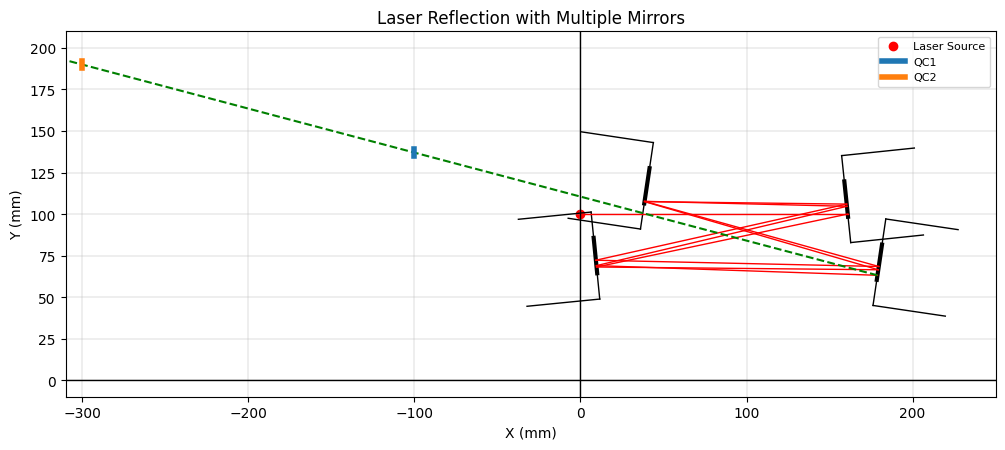

In [17]:
#import angle alignment functions from python classes (must download laser_align.py)

from laser_align import align_mirrors, AlignConfig

# m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy
# m1a0, m2a0, m3a0, m4a0

geom = dict(
    m1cx=m1cx, m1cy=m1cy,
    m2cx=m2cx, m2cy=m2cy,
    m3cx=m3cx, m3cy=m3cy,
    m4cx=m4cx, m4cy=m4cy,
)

# FIXED 4th-mirror angle:
m4a_fixed = float(m4a0)

# finite-difference steps (match your angle units: if degrees, use e.g. 1e-4)
m1da = m2da = m3da = 1e-4

def B_fn(alpha: np.ndarray) -> np.ndarray:
    m1a, m2a, m3a = map(float, alpha)
    return np.asarray(calc_B(
        geom['m1cx'], geom['m1cy'],
        geom['m2cx'], geom['m2cy'],
        geom['m3cx'], geom['m3cy'],
        geom['m4cx'], geom['m4cy'],
        m1a, m2a, m3a, m4a_fixed
    )).reshape(-1)


def J_fn(alpha: np.ndarray) -> np.ndarray:
    m1a, m2a, m3a = map(float, alpha)
    J = calc_jacobian(
        geom['m1cx'], geom['m1cy'],
        geom['m2cx'], geom['m2cy'],
        geom['m3cx'], geom['m3cy'],
        geom['m4cx'], geom['m4cy'],
        m1a, m2a, m3a, m4a_fixed,
        m1da, m2da, m3da
    )
    return np.asarray(J, float)   # already divided by 2*da in your code

# start with mirrors 1–3; mirror 4 is fixed at m4a_fixed
alpha0 = np.array([m1a0, m2a0, m3a0], float)

# original beta
print("B(alpha0) =", B_fn(alpha0))           # -> length-2

cfg = AlignConfig(damping=1e-3, tol_beta=1e-10, max_iters=5000, verbose=True)
res = align_mirrors(J_fn, B_fn, alpha0, cfg)

final_angles = np.array([res.alpha[0], res.alpha[1], res.alpha[2], m4a_fixed])
final_B = B_fn(res.alpha)
print("Converged:", res.converged, "iters:", res.iters, "\nreason:", res.reason)
print("Final Angles [m1, m2, m3, m4] =", final_angles)
print(f"Final β vector = {final_B}\n")

execution(
    m1cx, m1cy,
    m2cx, m2cy,
    m3cx, m3cy,
    m4cx, m4cy,
    final_angles[0], final_angles[1], final_angles[2], final_angles[3]
)

In [18]:
# --- Summaries of angle changes
alpha_init  = alpha0.astype(float)
alpha_final = res.alpha.astype(float)
delta_alpha = alpha_final - alpha_init

print("\nFinal angles:")
print(f"  m1: {alpha_final[0]:.9g}")
print(f"  m2: {alpha_final[1]:.9g}")
print(f"  m3: {alpha_final[2]:.9g}")
print(f"  m4 (fixed): {m4a_fixed:.9g}")

print("\nChange in angles (Δ = final − initial):")
print(f"  Δm1: {delta_alpha[0]:+.9g}")
print(f"  Δm2: {delta_alpha[1]:+.9g}")
print(f"  Δm3: {delta_alpha[2]:+.9g}")
print(f"  Δm4: {0.0:+.9g}  # fixed")

final_B = B_fn(res.alpha)
print("\nFinal β vector:", final_B)
print(f"‖β_final‖ = {np.linalg.norm(final_B):.6e}")



Final angles:
  m1: 95.9526966
  m2: 95.672223
  m3: 81.591822
  m4 (fixed): 81.519

Change in angles (Δ = final − initial):
  Δm1: +0.0101338439
  Δm2: -0.0142235435
  Δm3: -0.00100513709
  Δm4: +0  # fixed

Final β vector: [3.55271368e-12 7.75912667e-12]
‖β_final‖ = 8.533805e-12


In [19]:
#initialize mirror positions and angles

m1cx = 160
m1cy = 109 
m2cx = 8
m2cy = 75 
m3cx = 180
m3cy = 71 
m4cx = 40
m4cy = 117 
m1a0, m2a0, m3a0, m4a0 = 95.94256271, 95.68644659, 81.59282712, 81.519 
 

NOT CLIPPED, room to spare:  0.6275136153822611 mm
Laser Path: [(0, 100), (np.float64(160.9368171792799), np.float64(100.0)), (np.float64(8.700988216820722), np.float64(67.96015390876342)), (np.float64(179.32527238902372), np.float64(66.43470842934514)), (np.float64(38.59717219612299), np.float64(107.59211991631973)), (np.float64(160.29244620492904), np.float64(106.19047013379458)), (np.float64(8.26277904055583), np.float64(72.36097703623882)), (np.float64(179.6827862396747), np.float64(68.853691945386)), (np.float64(38.70674163099387), np.float64(108.32693291421795)), (np.float64(160.36180005138348), np.float64(105.52418792644923)), (np.float64(8.508465256635164), np.float64(69.89361295445549)), (np.float64(179.0303752471056), np.float64(64.43939741152454)), (np.float64(-786.9751771690931), np.float64(322.96071703734367))]
Total Laser Length: 1862.671712610642 mm
Total Number of Reflection (N_R) =  11


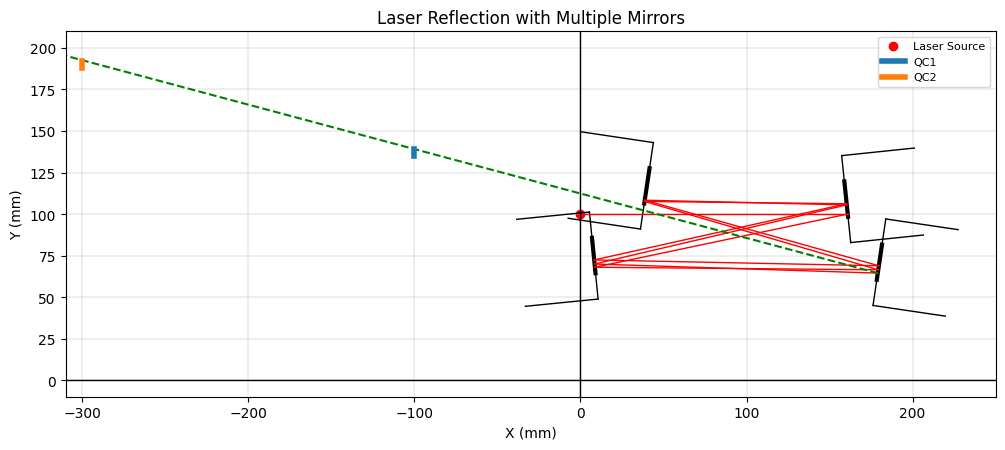

In [20]:
execution(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a0, m2a0, m3a0, m4a0)

B(alpha0) = [2.11319265 2.63696775]
J(alpha0) shape = (2, 4)
Converged: True iters: 5 
reason: ||B|| <= tol_beta
Final Angles [m1, m2, m3, m4] = [95.94256325 95.69240259 81.62276919 81.51995154]
Final β vector = [8.81072992e-13 4.03588274e-12]
NOT CLIPPED, room to spare:  2.3318872108668494 mm
Laser Path: [(0, 100), (np.float64(160.93681726480096), np.float64(100.0)), (np.float64(8.70171239206624), np.float64(67.96030331313504)), (np.float64(179.3329469280156), np.float64(66.47027008381146)), (np.float64(38.584454515520804), np.float64(107.50574952476263)), (np.float64(160.31166451926447), np.float64(106.0058401154933)), (np.float64(8.293984086057598), np.float64(72.05070222500025)), (np.float64(179.623465143797), np.float64(68.44308020716181)), (np.float64(38.61003237236434), np.float64(107.67730358795234)), (np.float64(160.45027150117073), np.float64(104.67424335268024)), (np.float64(8.618898082358363), np.float64(68.79111039060294)), (np.float64(178.83781230736247), np.float64(63.10

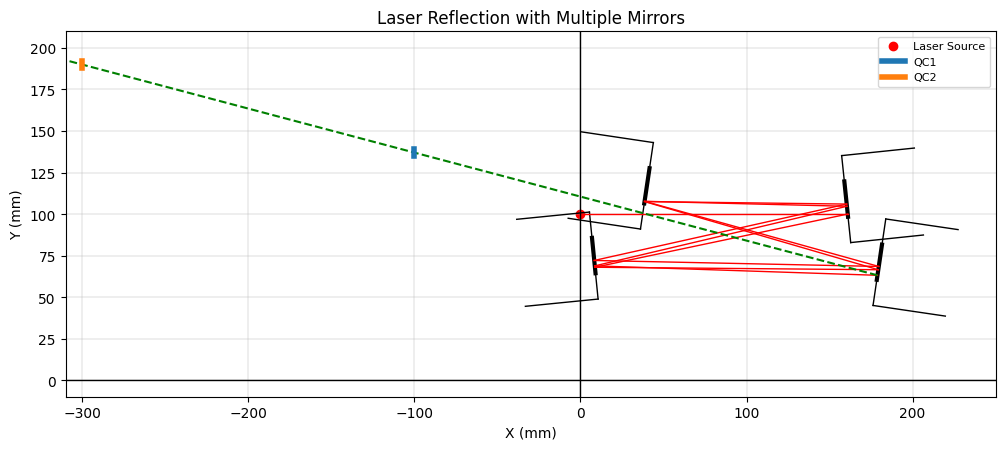

In [21]:
#ALL 4 MIRROR ANGLE ADJUSTER

# import angle alignment functions
from laser_align import align_mirrors, AlignConfig
import numpy as np

# m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy
# m1a0, m2a0, m3a0, m4a0  (ensure these are floats, no trailing commas)

geom = dict(
    m1cx=m1cx, m1cy=m1cy,
    m2cx=m2cx, m2cy=m2cy,
    m3cx=m3cx, m3cy=m3cy,
    m4cx=m4cx, m4cy=m4cy,
)

# finite-difference steps (match your angle UNITS: degrees or radians)
m1da = m2da = m3da = m4da = 1e-4

def B_fn(alpha: np.ndarray) -> np.ndarray:
    """Return [β1, β2] for mirrors 1–4 at angles alpha."""
    m1a, m2a, m3a, m4a = map(float, alpha)
    return np.asarray(
        calc_B(
            geom['m1cx'], geom['m1cy'],
            geom['m2cx'], geom['m2cy'],
            geom['m3cx'], geom['m3cy'],
            geom['m4cx'], geom['m4cy'],
            m1a, m2a, m3a, m4a
        ),
        dtype=float
    ).reshape(2,)

def J_fn(alpha: np.ndarray) -> np.ndarray:
    """
    Return 2x4 Jacobian dβ/dα at current angles.
    - First 3 columns: your calc_jacobian (already uses centered differences / (2*da)).
    - 4th column: centered finite difference w.r.t. m4a.
    """
    m1a, m2a, m3a, m4a = map(float, alpha)
    J = np.zeros((2, 4), float)

    # cols 0..2 from your function
    J[:, :3] = calc_jacobian(
        geom['m1cx'], geom['m1cy'],
        geom['m2cx'], geom['m2cy'],
        geom['m3cx'], geom['m3cy'],
        geom['m4cx'], geom['m4cy'],
        m1a, m2a, m3a, m4a,
        m1da, m2da, m3da
    )

    # col 3 via centered finite difference on m4
    Bp = np.asarray(calc_B(geom['m1cx'], geom['m1cy'], geom['m2cx'], geom['m2cy'],
                           geom['m3cx'], geom['m3cy'], geom['m4cx'], geom['m4cy'],
                           m1a, m2a, m3a, m4a + m4da), float)
    Bm = np.asarray(calc_B(geom['m1cx'], geom['m1cy'], geom['m2cx'], geom['m2cy'],
                           geom['m3cx'], geom['m3cy'], geom['m4cx'], geom['m4cy'],
                           m1a, m2a, m3a, m4a - m4da), float)
    J[:, 3] = (Bp - Bm) / (2.0 * m4da)

    return J

# start with mirrors 1–4 (all adjustable)
alpha0 = np.array([float(m1a0), float(m2a0), float(m3a0), float(m4a0)], float)

# sanity checks
print("B(alpha0) =", B_fn(alpha0))
print("J(alpha0) shape =", J_fn(alpha0).shape)  # should be (2,4)

# configure solver (no per-axis bias; you can leave caps None for equal treatment)
cfg = AlignConfig(damping=1e-3, tol_beta=1e-10, max_iters=5000,
                  line_search=True, per_axis_caps=None, verbose=True)

res = align_mirrors(J_fn, B_fn, alpha0, cfg)

final_angles = res.alpha.copy()
final_B = B_fn(final_angles)
print("Converged:", res.converged, "iters:", res.iters, "\nreason:", res.reason)
print("Final Angles [m1, m2, m3, m4] =", final_angles)
print("Final β vector =", final_B)

# plot with the solved angles
execution(
    geom['m1cx'], geom['m1cy'],
    geom['m2cx'], geom['m2cy'],
    geom['m3cx'], geom['m3cy'],
    geom['m4cx'], geom['m4cy'],
    final_angles[0], final_angles[1], final_angles[2], final_angles[3]
)


In [22]:
# --- Summaries of angle changes
alpha_init  = alpha0.astype(float)
alpha_final = res.alpha.astype(float)
delta_alpha = alpha_final - alpha_init

print("\nFinal angles:")
print(f"  m1: {alpha_final[0]:.9g}")
print(f"  m2: {alpha_final[1]:.9g}")
print(f"  m3: {alpha_final[2]:.9g}")
print(f"  m4: {alpha_final[3]:.9g}")

print("\nChange in angles (Δ = final − initial):")
print(f"  Δm1: {delta_alpha[0]:+.9g}")
print(f"  Δm2: {delta_alpha[1]:+.9g}")
print(f"  Δm3: {delta_alpha[2]:+.9g}")
print(f"  Δm4: {delta_alpha[3]:+.9g}")

final_B = B_fn(res.alpha)
print("\nFinal β vector:", final_B)
print(f"‖β_final‖ = {np.linalg.norm(final_B):.6e}")



Final angles:
  m1: 95.9425632
  m2: 95.6924026
  m3: 81.6227692
  m4: 81.5199515

Change in angles (Δ = final − initial):
  Δm1: +5.38608631e-07
  Δm2: +0.00595599593
  Δm3: +0.0299420672
  Δm4: +0.000951539253

Final β vector: [8.81072992e-13 4.03588274e-12]
‖β_final‖ = 4.130937e-12


In [76]:
#initialize mirror positions and angles

m1cx = 160
m1cy = 109 
m2cx = 12
m2cy = 75 
m3cx = 180
m3cy = 71 
m4cx = 40
m4cy = 117 
m1a0, m2a0, m3a0, m4a0 = 94.81351, 94.00237065, 80.16631263, 79.37601315
alpha0 = np.array([m1a0,m2a0,m3a0,m4a0])

geom = dict(
    m1cx=m1cx, m1cy=m1cy,
    m2cx=m2cx, m2cy=m2cy,
    m3cx=m3cx, m3cy=m3cy,
    m4cx=m4cx, m4cy=m4cy,
)


NOT CLIPPED, room to spare:  4.28678568819636 mm
Laser Path: [(0, 100), (np.float64(160.75788826772197), np.float64(100.0)), (np.float64(12.016089194381578), np.float64(74.77005052745982)), (np.float64(179.82966130380555), np.float64(70.01728933075373)), (np.float64(39.74763676757679), np.float64(115.65462429622907)), (np.float64(160.00631053435097), np.float64(108.92506176493605)), (np.float64(11.98501193699266), np.float64(75.21421191771294)), (np.float64(178.29698967446976), np.float64(61.17506618212049)), (np.float64(-788.3379113405871), np.float64(317.3331582651373))]
Total Laser Length: 1250.4468400781404 mm
Total Number of Reflection (N_R) =  7


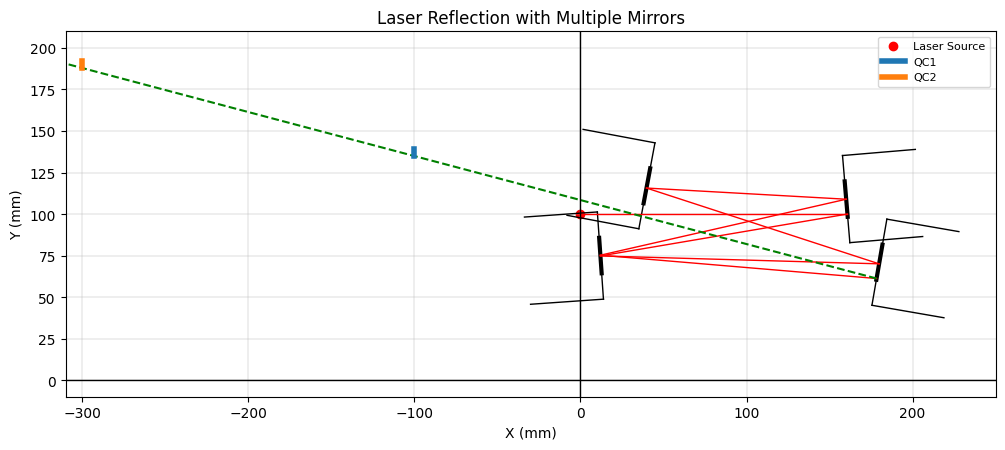

In [77]:
execution(m1cx, m1cy, m2cx, m2cy, m3cx, m3cy, m4cx, m4cy, m1a0, m2a0, m3a0, m4a0)

In [78]:
print(B_fn(alpha0))

[-2.07627666 -2.07630908]


B(alpha0) = [-2.07627666 -2.07630908]
Converged: False iters: 123 
reason: Stalled (tiny step)
Final Angles [m1, m2, m3, m4] = [94.81350896 94.15507826 80.34025243 79.41847978]
Final β vector = [-1.07775406e-08  4.35619540e-09]
NOT CLIPPED, room to spare:  2.27526490804345 mm
Laser Path: [(0, 100), (np.float64(160.75788810266502), np.float64(100.0)), (np.float64(12.016697283884374), np.float64(74.77015927426527)), (np.float64(179.98450745781636), np.float64(70.90897991731971)), (np.float64(39.894296357808216), np.float64(116.43416831308119)), (np.float64(159.93210847080746), np.float64(109.80621896634071)), (np.float64(11.912021108700657), np.float64(76.21104320712294)), (np.float64(178.6645147267659), np.float64(63.153903565543324)), (np.float64(-787.9703474729444), np.float64(319.3121421216106))]
Total Laser Length: 1251.0372973874044 mm
Total Number of Reflection (N_R) =  7


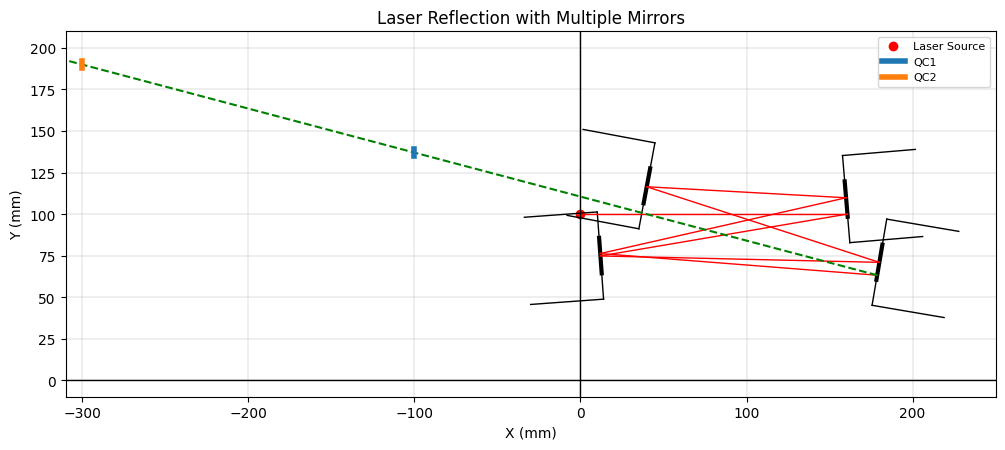

In [79]:
# -------------------------------
# Centering & safety for alignment
# -------------------------------

import numpy as np

# ---- Tunables ----
bias_mirrors = [1,2,4]   # e.g. [2] or [1,2,3,4]; None => include ALL mirrors
w_center     = 1e-6   # increase to pull spots inward more strongly (e.g., 1e-2 … 1e0)
edge_margin  = 0.05   # keep >=4% of usable radius away from the edge
p_edge       = 2.0    # edge emphasis (2–4 typical). Higher => stronger push from the rim
PENALTY      = 1e6
_eps         = 1e-4   # tiny epsilon

# ---- Mirror centers & usable radii (mm) ----
centers_dict = {
    1: (m1cx, m1cy),
    2: (m2cx, m2cy),
    3: (m3cx, m3cy),
    4: (m4cx, m4cy),
}

radii = {1: 10.7, 2: 10.7, 3: 10.7, 4: 10.7}
mirror_lengths = [21.4, 21.4, 21.4, 21.4]

def _wrap_deg(a):
    a = np.asarray(a, float)
    return ((a + 180.0) % 360.0) - 180.0


# ---- Build mirror segments for a given angle vector (deg) ----
#def _build_mirrors_from_alpha(alpha_deg, mirror_centers, mirror_lengths):

def _build_mirrors_from_alpha(alpha_deg, mirror_centers, mirror_lengths):
    mirrors = []
    for center, length, angle_deg in zip(mirror_centers, mirror_lengths, alpha_deg):
        mirrors.append(calculate_mirror_endpoints(center, length, angle_deg))
    return mirrors

# ---- Trace the same way your plot does (returns ALL hits in order) ----
def trace_hits_for_solver(alpha_deg, max_reflections=64):
    """
    Returns:
      hits: list of (mi, (x, y)) in time order
      path: list of path points (start + intersections + final far point)
    Uses your same geometry + reflect_laser().
    """
    alpha_deg = np.asarray(alpha_deg, float).reshape(-1)
    alpha_deg = _wrap_deg(alpha_deg).reshape(-1)
    if alpha_deg.size != 4:
        raise ValueError("Expected 4 angles [m1a, m2a, m3a, m4a] in degrees.")

    mirror_centers = [centers_dict[1], centers_dict[2], centers_dict[3], centers_dict[4]]
    mirrors = _build_mirrors_from_alpha(alpha_deg, mirror_centers, mirror_lengths)

    hits = []
    path = [laser_start]
    pos  = laser_start
    ang  = laser_angle
    last = None

    for _ in range(max_reflections):
        inter, ref_end, hit_seg = reflect_laser(pos, ang, mirrors, last)
        if inter is None:
            # extend a far point like your plotter does
            far = (pos[0] + np.cos(np.radians(ang)) * 1000,
                   pos[1] + np.sin(np.radians(ang)) * 1000)
            path.append(far)
            break

        path.append(inter)

        # identify which mirror (1..4) was hit
        mi = None
        for i, seg in enumerate(mirrors, start=1):
            # accept either endpoint order
            if (np.allclose(hit_seg, seg) or np.allclose(hit_seg, seg[::-1])):
                mi = i
                break
        if mi is None:
            # fallback: choose segment with min distance to intersection
            dmin, mi = 1e9, None
            ix, iy = inter
            for i, seg in enumerate(mirrors, start=1):
                (ax, ay), (bx, by) = seg
                abx, aby = (bx-ax), (by-ay)
                ab2 = abx*abx + aby*aby
                if ab2 == 0.0:
                    d = np.hypot(ix-ax, iy-ay)
                else:
                    t = max(0.0, min(1.0, ((ix-ax)*abx + (iy-ay)*aby)/ab2))
                    px, py = ax + t*abx, ay + t*aby
                    d = np.hypot(ix-px, iy-py)
                if d < dmin:
                    dmin, mi = d, i

        hits.append((mi, (float(inter[0]), float(inter[1]))))

        # advance the ray
        pos  = inter
        ang  = np.degrees(np.arctan2(ref_end[1] - inter[1], ref_end[0] - inter[0]))
        last = hit_seg

    return hits, path

# ---- Hard safety: reject any alpha where any hit is outside safe radius ----
def violates_safe_radius_all(alpha):
    hits, _ = trace_hits_for_solver(alpha)
    for mi, (x, y) in hits:
        cx, cy = centers_dict[mi]
        R      = radii[mi]
        Rsafe  = R * (1.0 - edge_margin)
        if np.hypot(x - cx, y - cy) > Rsafe:
            return True
    return False

# ---- Edge-aware soft-centering residual using all hits ----
def _edge_weight(d, Rsafe):
    # Blow up near the rim: weight ~ (rho/(1-rho))^p, with rho=d/Rsafe in [0,1)
    rho = np.clip(d / max(Rsafe, _eps), 0.0, 1.0 - 1e-6)
    return (rho / max(1.0 - rho, 1e-6)) ** p_edge

def S_all_fn(alpha):
    """
    Soft-centering residual from all reflections (same trace as the plot).
    Normalized by usable radius and up-weighted near the safe boundary.
    """
    alpha = _wrap_deg(alpha)
    hits, _ = trace_hits_for_solver(alpha)
    terms = []
    for mi, (x, y) in hits:
        if (bias_mirrors is not None) and (mi not in bias_mirrors):
            continue
        cx, cy = centers_dict[mi]
        R      = radii[mi]
        Rsafe  = R * (1.0 - edge_margin)
        d      = np.hypot(x - cx, y - cy)
        s      = np.sqrt(1.0 + _edge_weight(d, Rsafe))   
        terms += [ s * (x - cx)/R,  s * (y - cy)/R ]
    return np.asarray(terms, float) if terms else np.zeros(0, float)



# ---- Robust finite-difference Jacobian for S_all_fn (pads when hit-count changes) ----
def _pad_to_len(v, m):
    v = np.asarray(v, float).reshape(-1)
    if v.size == m: return v
    if v.size >  m: return v[:m]
    out = np.zeros(m, float); out[:v.size] = v
    return out

def S_all_J_fn(alpha, da=1e-4):
    alpha = _wrap_deg(alpha)
    base = S_all_fn(alpha)
    m = base.size
    n = len(alpha)
    JS = np.zeros((m, n), float)
    if m == 0:
        return JS
    for k in range(n):
        ap = np.array(alpha, float); am = np.array(alpha, float)
        ap[k] += da; am[k] -= da
        vp = _pad_to_len(S_all_fn(ap), m)
        vm = _pad_to_len(S_all_fn(am), m)
        JS[:, k] = (vp - vm) / (2.0 * da)
    return JS

# ---- Augmented residuals/Jacobian for the solver ----
def B_aug_all_fn(alpha):
    return np.concatenate([B_fn(alpha), np.sqrt(w_center) * S_all_fn(alpha)])

def J_aug_all_fn(alpha):
    alpha = _wrap_deg(alpha)
    return np.vstack([J_fn(alpha), np.sqrt(w_center) * S_all_J_fn(alpha)])

def B_aug_all_safe_fn(alpha):

    if violates_safe_radius_all(alpha):
        base = B_aug_all_fn(alpha)
        return np.full_like(base, PENALTY)  # forces line search to backtrack
    return B_aug_all_fn(alpha)

# -------------------------------

# -------------------------------

alpha0 = np.array([m1a0, m2a0, m3a0, m4a0])
cfg = AlignConfig(
    damping=1e-3,
    tol_beta=1e-6,     
    max_iters=500,
    line_search=True,
    per_axis_caps=None,
    verbose=True,
)

res = align_mirrors(J_aug_all_fn, B_aug_all_safe_fn, alpha0, cfg)
final_angles = res.alpha.copy()
final_B = B_fn(final_angles)

print("B(alpha0) =", B_fn(alpha0))
print("Converged:", res.converged, "iters:", res.iters, "\nreason:", res.reason)
print("Final Angles [m1, m2, m3, m4] =", final_angles)
print("Final β vector =", final_B)

# Plot with solved angles
execution(
    m1cx, m1cy,
    m2cx, m2cy,
    m3cx, m3cy,
    m4cx, m4cy,
    final_angles[0], final_angles[1], final_angles[2], final_angles[3]
)


In [50]:
# --- Summaries of angle changes
alpha_init  = alpha0.astype(float)
final_angles = res.alpha.astype(float)
delta_alpha = final_angles - alpha_init

print("\nFinal angles:")
print(f"  m1: {final_angles[0]:.9g}")
print(f"  m2: {final_angles[1]:.9g}")
print(f"  m3: {final_angles[2]:.9g}")
print(f"  m4: {final_angles[3]:.9g}")

print("\nChange in angles (Δ = final − initial):")
print(f"  Δm1: {delta_alpha[0]:+.9g}")
print(f"  Δm2: {delta_alpha[1]:+.9g}")
print(f"  Δm3: {delta_alpha[2]:+.9g}")
print(f"  Δm4: {delta_alpha[3]:+.9g}")

final_B = B_fn(res.alpha)
print("\nFinal β vector:", final_B)
print(f"‖β_final‖ = {np.linalg.norm(final_B):.6e}")


Final angles:
  m1: 95.8991059
  m2: 97.6956368
  m3: 81.9816843
  m4: 77.7912879

Change in angles (Δ = final − initial):
  Δm1: +0
  Δm2: -1.1397816e-09
  Δm3: +3.02961212e-10
  Δm4: +4.48085302e-09

Final β vector: [ 0.00055574 -0.00043362]
‖β_final‖ = 7.048962e-04
